# Design Guide : Folded cascode in switch capacitor integrator 

## Import libs

In [40]:
import numpy as np
import scipy.constants as sc
import catppuccin
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
pmos4 = lk('../../lookup_table/035/pmos4.mat')
nmos4 = lk('../../lookup_table/035/nmos4.mat')
import sys; sys.path.append('../..')
import adri
from scipy.interpolate import interp1d
def interp1(x, y, value):
    # Interpolation function
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)


## STEP 1 : Specs

In [41]:
#Design Spec 
s = {
    'ts'        : 50e-9,
    'ed'        : 0.1/100,
    'fu1'       : 0,
    'vod_noise' : 90e-6,
    'FO'        : 4,
    'G'         : 1/4,
    'vod_final' : 0.2,
    'beta_max' : 0,
    'VDD' : 2.7,
    'VCM' : 1.35,
    'V_SWING_P2P_DIFF' : 1.8,
    #'L0' : 0
    
}
s['beta_max'] = 1 / (1 + s['G'])
s['fu1'] = 1 / (2 * np.pi) * np.log(1 / s['ed']) / s['ts']

# Constants for another design
d = {
    'gamma': 0.8,
    'Lcas': 0,
    'gm_IDcas': 0,
    'cself': 0,
    'gm_ID1': 0,
    'beta': np.array([s['beta_max'] * 3/4]),
    'fp2' : 0,
}

## STEP 2 : Sizing the output branch

### Compute minimum GM_ID of output branch with output common mode min/max,
Increasing gm_id, increase the total size of the MOS, reducing bandwidth
#### $\frac {gm} {id} = \frac {2}{V_{ov}} $

In [58]:
beta_max = s['beta_max']
beta = 3/4 * beta_max
kappa = 0.7

VDD = s['VDD']
VCM = s['VCM']
V_SWING_P2P_DIFF = s['V_SWING_P2P_DIFF']
VOUT_CM_HIGH = VCM+V_SWING_P2P_DIFF/2
VOUT_CM_LOW = VCM-V_SWING_P2P_DIFF/2
VDS_MOS = VOUT_CM_LOW/2
print('2 MOS pour', VOUT_CM_LOW)
gm_id = 2/(VDS_MOS)
print('gm_id > ', gm_id)

2 MOS pour 0.45000000000000007
gm_id >  8.888888888888888


### Choose GM_ID output cascode

In [43]:
d['gm_IDcas'] = np.array([15])
print('On prend gm_IDcas =', d['gm_IDcas'])

On prend gm_IDcas = [15]


### Compute Gain L0, with Lcascode sweep

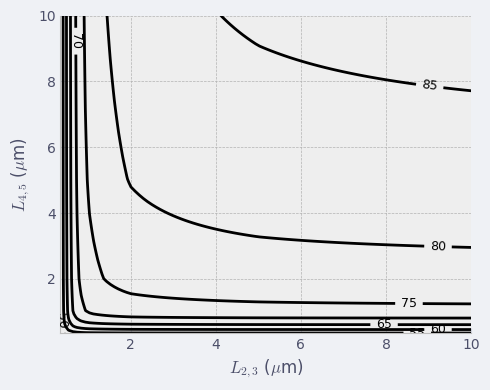

In [44]:
#Set L sweep for plot 
L = np.linspace(0.35, 10, 100)

#Compute gain param
gm_gds2 = nmos4.lookup('GM_GDS', GM_ID = d['gm_IDcas'], L = L, VDS = VDS_MOS, VSB = 0)
gm_gds3 = nmos4.lookup('GM_GDS', GM_ID = d['gm_IDcas'], L = L, VDS = VCM-VDS_MOS, VSB = VDS_MOS)
gm_gds4 = pmos4.lookup('GM_GDS', GM_ID = d['gm_IDcas'], L = L, VDS = VCM-VDS_MOS, VSB = VDS_MOS)
gm_gds5 = pmos4.lookup('GM_GDS', GM_ID = d['gm_IDcas'], L = L, VDS = VDS_MOS, VSB = 0)

L0 = np.zeros((len(L), len(L)))
#Copute L0 for range of Lcascode
for i in range(len(L)):
    L0[i, :] = beta * kappa / (1/((1+gm_gds5)*gm_gds4) + 1/((1+1/3*gm_gds2[i])*gm_gds3[i]))
L0 = 20*np.log10(L0)
# Plotting
fig, ax = plt.subplots(figsize=(5, 4))
C = ax.contour(L, L, L0, colors='k', levels=8)
ax.clabel(C, fmt='%d', fontsize=9)
ax.set_xlabel(r'$L_{2,3}$ ($\mu$m)')
ax.set_ylabel(r'$L_{4,5}$ ($\mu$m)')
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({"axes.grid": True})
plt.tight_layout()
plt.show()

### Choose L cascode

In [45]:
#Choose length
d['Lcas'] = np.array([1.6])
print('On prend L_cascode =', d['Lcas'])

On prend L_cascode = [1.6]


### Compute 2nd pole with casocde sizing
Aim for FP1 / FU1 == 4 for 75° phase margin => Best for settling

In [46]:

gmb_gm3 =   nmos4.lookup('GMB_GM', GM_ID = d['gm_IDcas'], L = d['Lcas'], VDS =  VCM-VDS_MOS, VSB = VDS_MOS)
gm_css3 =   nmos4.lookup('GM_CSS', GM_ID = d['gm_IDcas'], L = d['Lcas'], VDS =  VCM-VDS_MOS, VSB = VDS_MOS)
cdd_css3 =  nmos4.lookup('CDD_CSS', GM_ID = d['gm_IDcas'], L = d['Lcas'], VDS =  VCM-VDS_MOS, VSB = VDS_MOS)
cdd_w3  =   nmos4.lookup('CDD_CSS', GM_ID = d['gm_IDcas'], L = d['Lcas'], VDS =  VCM-VDS_MOS, VSB = VDS_MOS)
cdd_w2  =   nmos4.lookup('CDD_CSS', GM_ID = d['gm_IDcas'], L = d['Lcas'], VDS = VDS_MOS, VSB = 0) 

# Nondominant pole frequency
d['fp2'] = 1 / (2 * np.pi) * gm_css3 * (1 + gmb_gm3) / (1 + 2 * cdd_css3 * 2 * (cdd_w2 / cdd_w3))
print(f'Nondominant pole frequency: {d['fp2'] * 1e-9:.3f} GHz')
#print("FP2 / FU1 == 4 for 75° phase margin and fatest settling")
adri.cool_print(d['fp2'] / s['fu1'])

Nondominant pole frequency: 0.096 GHz
d['fp2'] / s['fu1'] = np.float64(4.356917745010365)


## Step 3 : sizing input diff pair

### folded_cascode() : Find Lowest current & Rself for a list of L1 with gm_id1 and beta sweeps
Sweep L1, measure performance, choose L1

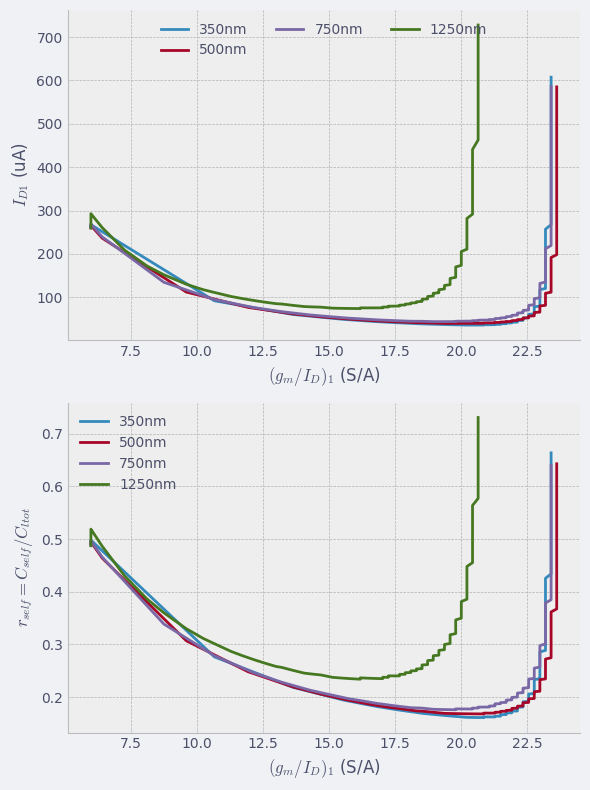

In [47]:
# Channel length sweep
L1 = [0.35, 0.5, 0.75, 1.25]
#L1 = pmos4['L']
m1 = []
p = []
d['gm_ID1'] = np.linspace(6, 27, 100)
d['beta'] = s['beta_max'] * np.linspace(0.2, 1, 100)

for Li in L1:
    d['L1'] = Li
    mi,m2,m3,m4,m5,pi = adri.folded_cascode(nmos4, pmos4, s, d)
    m1.append(mi)
    p.append(pi)

# Plotting setup
plt.style.use("bmh")
fig, axs = plt.subplots(2, 1, figsize=(6, 8))
# Plot ID versus gm/ID for different L values
for i, length in enumerate(L1):
    label = f'{length * 1e3:.0f}nm'  # Convert L from meters to nm for label
    axs[0].plot(m1[i]['GM_ID'], m1[i]['ID'] * 1e6, label=label)  # ID in mA
axs[0].set_xlabel(r'$(g_m/I_D)_1$ (S/A)')
axs[0].set_ylabel(r'$I_{D1}$ (uA)')
axs[0].legend(loc='upper center', ncol=3, frameon=False)
axs[0].grid(True)

# Plot cself/cltot versus gm/ID for different L values
for i, length in enumerate(L1):
    label = f'{length * 1e3:.0f}nm'
    axs[1].plot(m1[i]['GM_ID'], p[i]['cself'] / p[i]['cltot'], label=label)
axs[1].set_xlabel(r'$(g_m/I_D)_1$ (S/A)')
axs[1].set_ylabel(r'$r_{self} = C_{self}/C_{ltot}$')
axs[1].legend(loc='best', frameon=False)
axs[1].grid(True)

plt.tight_layout()
plt.show()



In [48]:
d['L1'] = 0.75
print('On prend L1 =', d['L1'])

On prend L1 = 0.75


### Option 1 : Choose GM_ID1 and BETA for first design all sized

In [49]:
d['gm_ID1'] = np.array([20])
d['beta'] =  np.array([s['beta_max'] * 3/4])

m1,m2,m3,m4,m5,p = adri.folded_cascode(nmos4, pmos4, s, d)

adri.print_design_summary(s, d,m1,m2,m3,m4,m5,p)


### Option 2 : Optimization Self loading loop : Set gm_ID and beta sweep => Sizing W,L 
folded_cascode(), find optimal gm_id for a beta, then the loop take the beta with the lowest current, then the Cself loop add self loading and iterate a few time

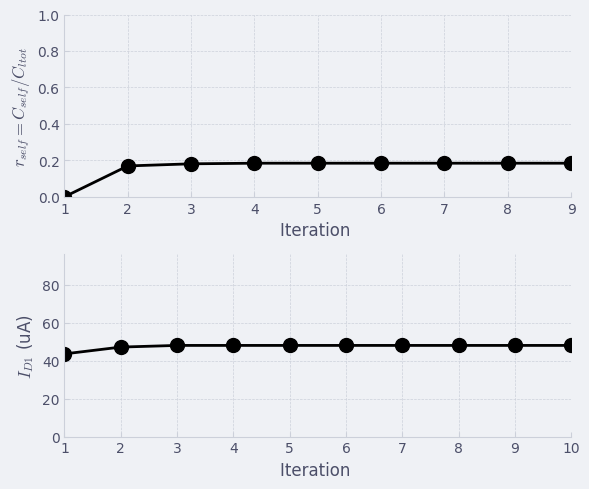

In [50]:
d['gm_ID1'] =  np.linspace(5, 28, 100)
d['beta']   =  beta_max * np.linspace(0.2, 1, 100)

# Self loading sweep
cself = np.zeros(10)
ID1 = np.zeros_like(cself)
gm_ID1 = np.zeros_like(cself)
cltot = np.zeros_like(cself)
beta = np.zeros_like(cself)

for i in range(len(cself)):
    d['cself'] = cself[i]
    m1,m2,m3,m4,m5,p = adri.folded_cascode(nmos4, pmos4, s, d)
    ID1[i] = np.min(m1['ID'])
    m = np.argmin(m1['ID'])
    gm_ID1[i] = m1['GM_ID'][m]
    cltot[i] = p['cltot'][m]
    beta[i] = d['beta'][m]

    if i + 1 < len(cself):
        cself[i + 1] = p['cself'][m]

# Plotting results
plt.style.use(catppuccin.PALETTE.latte.identifier)
fig, axs = plt.subplots(2, 1, figsize=(6, 5))
# r_self vs iteration
axs[0].plot(range(1, len(cself)), cself[:-1] / cltot[:-1], 'k-o', linewidth=2, markersize=10)
axs[0].set_xlabel('Iteration ')
axs[0].set_ylabel(r'$r_{self} = C_{self}/C_{ltot}$')
axs[0].set_xlim([1, len(cself) - 1])
axs[0].set_ylim([0, 1])
axs[0].grid(True)
# ID1 vs iteration
axs[1].plot(range(1, len(ID1) + 1), ID1 * 1e6, 'k-o', linewidth=2, markersize=10)
axs[1].set_xlabel('Iteration ')
axs[1].set_ylabel(r'$I_{D1}$ (uA)')
axs[1].set_xlim([1, len(ID1)])
axs[1].set_ylim([0, ID1[-1]* 1e6*2])
axs[1].grid(True)

plt.tight_layout()
plt.show()

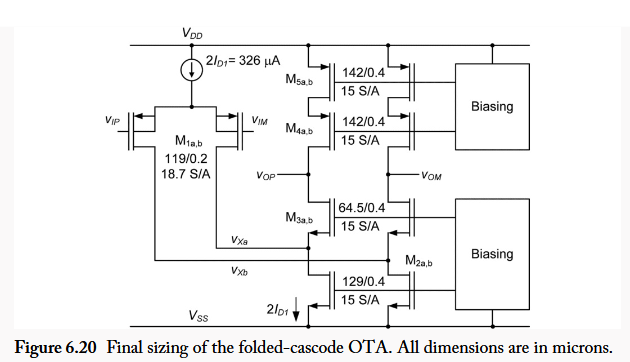  
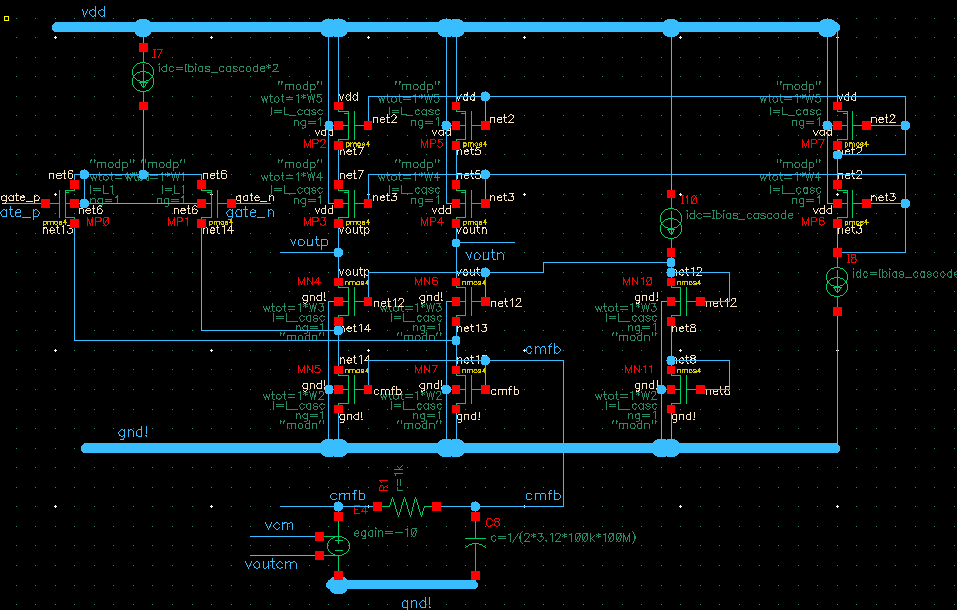

In [51]:
# Final sizing point
ID1_opt = ID1[-1]
gm_ID1_opt = gm_ID1[-1]
beta_opt = beta[-1]

#Set param of optimum point then run sim to get all param
d['gm_ID1'] =  np.array([gm_ID1_opt])
d['beta'] =  np.array([beta_opt])
m1,m2,m3,m4,m5,p = adri.folded_cascode(nmos4, pmos4, s, d)
adri.print_design_summary(s,d,m1,m2,m3,m4,m5,p)

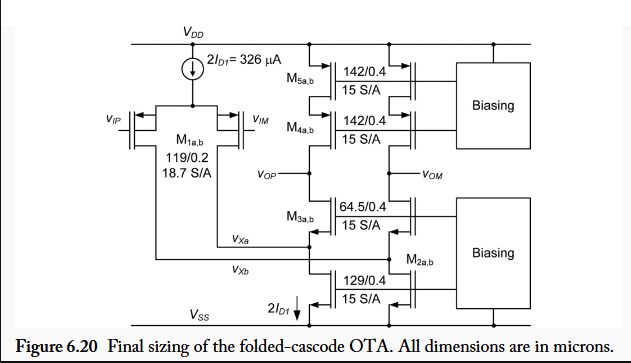 
  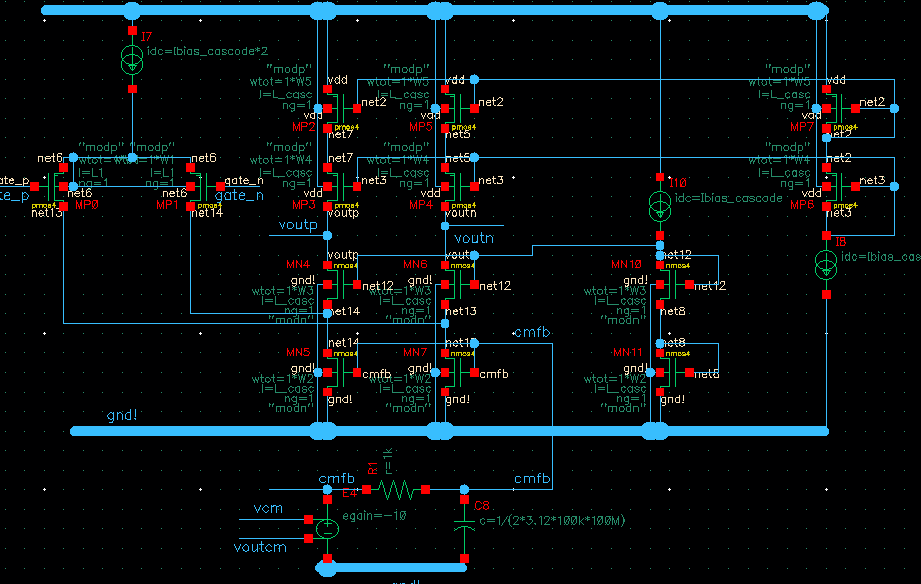

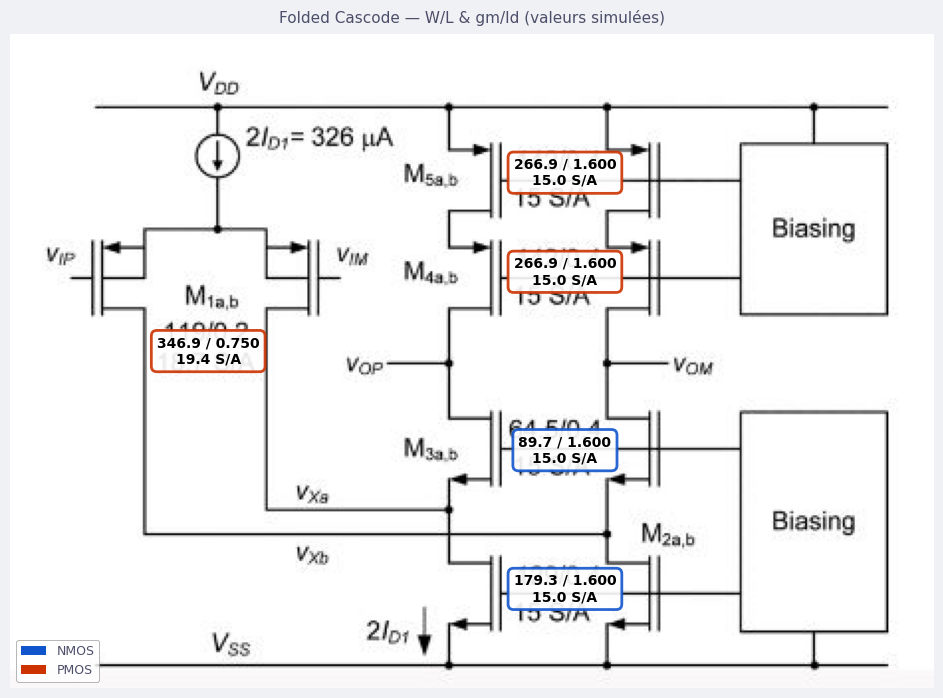

In [52]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from PIL import Image

# ─────────────────────────────────────────────────────────
# 1. Appel de la fonction de sizing
# ─────────────────────────────────────────────────────────
m1, m2, m3, m4, m5, p = adri.folded_cascode(nmos4, pmos4, s, d)

def sc(val):
    return float(np.asarray(val).flat[0])

mos_list = {"M1": m1, "M2": m2, "M3": m3, "M4": m4, "M5": m5}

# ─────────────────────────────────────────────────────────
# 2. Chargement de l'image
# ─────────────────────────────────────────────────────────
IMG_PATH = "folded_cascode.png"   # ← adapte si besoin
img = Image.open(IMG_PATH)
W_px, H_px = img.size             # 512 × 345

fig, ax = plt.subplots(figsize=(10, 10 * H_px / W_px))
ax.imshow(img, extent=[0, W_px, H_px, 0])
ax.axis("off")

annot_pos = {
    "M5": (280, 70),
    "M4": (280, 120),
    "M3": (280, 210),
    "M1": (100, 160),
    "M2": (280, 280),
}

PMOS_C = "#cc3300"
NMOS_C = "#1155cc"
mos_color = {"M1": PMOS_C, "M2": NMOS_C, "M3": NMOS_C,
             "M4": PMOS_C, "M5": PMOS_C}

for name, (px, py) in annot_pos.items():
    m     = mos_list[name]
    W_um  = sc(m['W'])       
    L_um  = sc(m['L'])     
    gmid  = sc(m['GM_ID'])
    color = mos_color[name]

    ax.annotate(
        f"{W_um:.1f} / {L_um:.3f}\n{gmid:.1f} S/A",
        xy=(px, py),
        fontsize=10,
        color="black",
        fontweight="bold",
        ha="center", va="center",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            edgecolor=color,
            linewidth=2,
            alpha=0.9,
        ),
    )

# Légende
ax.legend(
    handles=[
        mpatches.Patch(facecolor=NMOS_C, label="NMOS"),
        mpatches.Patch(facecolor=PMOS_C, label="PMOS"),
    ],
    loc="lower left", fontsize=9,
    facecolor="white", edgecolor="gray",
)

ax.set_title("Folded Cascode — W/L & gm/Id (valeurs simulées)", fontsize=11, pad=8)

plt.tight_layout()
plt.show()